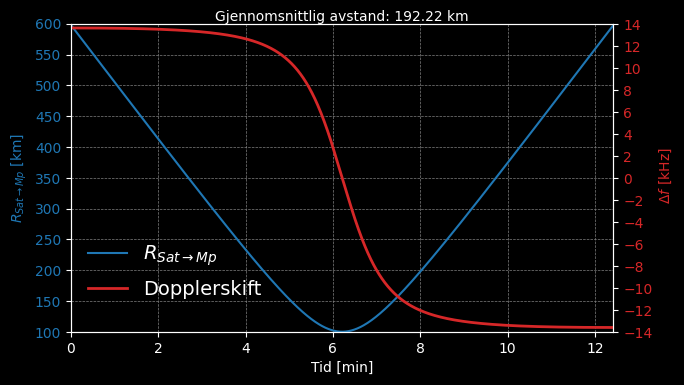

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

h = 100e3 # km
R_moon = 1737.4e3 # km
a = R_moon + h

m_moon = 7.34767309e22 # kg
G = 6.67430e-11 # m^3 kg^-1 s^-2
T_orbital = 2 * np.pi * np.sqrt((a)**3 / (G * m_moon)) # s
v_orbital = 2 * np.pi * a / T_orbital # m/s

#print(T_orbital/60) # h

psi = np.linspace(90, 270, 1000) # degrees
psi= np.deg2rad(psi) # rad

theta = np.asin((R_moon/a) * np.sin(psi)) # rad
phi = np.pi - psi - theta

R_sat_meas = a* (np.sin(phi) / np.sin(psi))
R_sat_meas = R_sat_meas * 1e-3 # km

t = (a * (phi + phi[0]) / v_orbital) / 60  # s

SAR_freq = 1.25e9 # Hz
c = 3e8 # m/s

doppler = -(2 * SAR_freq * v_orbital / c) * np.sin(psi) *1e-3 # Hz


fig, ax1 = plt.subplots(figsize=(7, 4))

# Plot R_sat_meas on the left y-axis
ax1.plot(t, R_sat_meas, label=r'$R_{Sat \rightarrow Mp}$', color='tab:blue')
ax1.set_xlabel('Tid [min]')
ax1.set_ylabel(r'$R_{Sat \rightarrow Mp}$ [km]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_yticks(np.arange(100, 600+1, 50)) # Set y-ticks for R_sat_meas
ax1.set_ylim(100, 600)
ax1.set_xlim(min(t), max(t)) # Set x-axis limits to match the time range
ax1.grid(linewidth=0.5, linestyle='--',color='gray')
ax1.legend(loc='lower left', fontsize=14, frameon=False, bbox_to_anchor = [0.0, 0.15])
ax1.annotate(f'Gjennomsnittlig avstand: {np.mean(R_sat_meas):.2f} km', xy=(0.5, 1), xycoords='axes fraction',
            fontsize=10, ha='center', va='bottom', color='white')
# Create a second y-axis for Doppler
ax2 = ax1.twinx()
ax2.plot(t, doppler, label='Dopplerskift', color='tab:red',linewidth=2)
ax2.set_ylabel(r' $\Delta f$ [kHz]', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_yticks(np.arange(-14, 14+0.1, 2)) # Set y-ticks for Doppler
ax2.set_ylim(-14, 14) # Set y-axis limits for Doppler
ax2.legend(loc='lower left', fontsize=14, frameon=False, bbox_to_anchor = [0.0, 0.05])

# Title and show the plot
#plt.title('Sattellitt avstand til målepunkt og Doppler vs tid')
plt.savefig('Figurer/Synlighetsperiode.pdf', bbox_inches='tight')
plt.show()
